<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/14-Semana/PracticaValidacionEvaluacion_Seleccion_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📦 Dataset sugerido
Usa el conjunto de datos Glioma Grading Clinical and Mutation Features. Este conjunto de datos lo puedes encontrar en https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

📝 Actividades

El cuaderno deberá contener las siguientes secciones:

#  1. Carga de Bibliotecas, Conjunto de Datos y Análisis Exploratorio de los Datos

Declarar las bibliotecas necesarias para este proyecto
Cargar el conjunto de datos Glioma Grading Clinical and Mutation Features. Se puede descargar de https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

In [135]:
#Montar google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

In [137]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/TCGA_InfoWithGrade.csv')

# 2. 📊 Análisis exploratorio de datos (EDA)

Realiza un análisis inicial de los datos antes de modelar:

Describir forma y estructura (shape, describe(), info()).



In [138]:
# Describir el dataset
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())


   Grade  Gender  Age_at_diagnosis  Race  IDH1  TP53  ATRX  PTEN  EGFR  CIC  \
0      0       0             51.30     0     1     0     0     0     0    0   
1      0       0             38.72     0     1     0     0     0     0    1   
2      0       0             35.17     0     1     1     1     0     0    0   
3      0       1             32.78     0     1     1     1     0     0    0   
4      0       0             31.51     0     1     1     1     0     0    0   

   ...  FUBP1  RB1  NOTCH1  BCOR  CSMD3  SMARCA4  GRIN2A  IDH2  FAT4  PDGFRA  
0  ...      1    0       0     0      0        0       0     0     0       0  
1  ...      0    0       0     0      0        0       0     0     0       0  
2  ...      0    0       0     0      0        0       0     0     0       0  
3  ...      0    0       0     0      0        0       0     0     1       0  
4  ...      0    0       0     0      0        0       0     0     0       0  

[5 rows x 24 columns]
(839, 24)
            Grade 

Mostrar la distribución de clases (y.value_counts()).

Visualizar:

- Histograma de al menos 3 variables numéricas.

- Boxplots o violin plots por clase si es computacionalmente viable.

- Mapa de calor de correlaciones entre variables.


In [139]:
# Distribución de las clases
print("Distribución de clases :\n")
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

Distribución de clases :


--- Grade ---
Grade
0    487
1    352
Name: count, dtype: int64

--- Gender ---
Gender
0    488
1    351
Name: count, dtype: int64

--- Age_at_diagnosis ---
Age_at_diagnosis
52.67    3
72.53    3
64.82    3
35.19    3
41.32    3
        ..
32.46    1
44.36    1
40.29    1
44.72    1
39.77    1
Name: count, Length: 766, dtype: int64

--- Race ---
Race
0    765
1     59
2     14
3      1
Name: count, dtype: int64

--- IDH1 ---
IDH1
0    435
1    404
Name: count, dtype: int64

--- TP53 ---
TP53
0    491
1    348
Name: count, dtype: int64

--- ATRX ---
ATRX
0    622
1    217
Name: count, dtype: int64

--- PTEN ---
PTEN
0    698
1    141
Name: count, dtype: int64

--- EGFR ---
EGFR
0    727
1    112
Name: count, dtype: int64

--- CIC ---
CIC
0    728
1    111
Name: count, dtype: int64

--- MUC16 ---
MUC16
0    741
1     98
Name: count, dtype: int64

--- PIK3CA ---
PIK3CA
0    766
1     73
Name: count, dtype: int64

--- NF1 ---
NF1
0    772
1     67
Name: count, dt

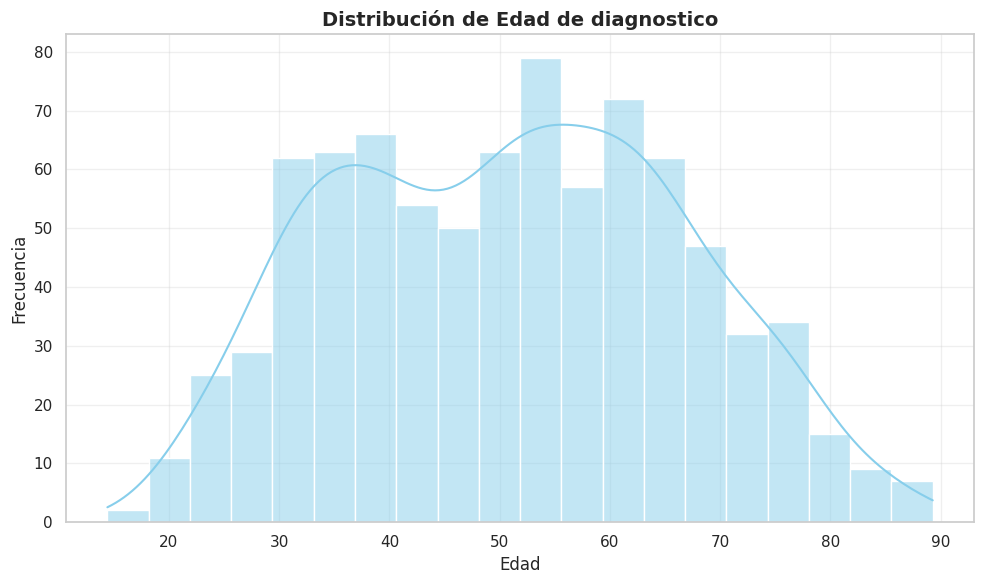

In [140]:
# Histogramas
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Edad de diagnostico
sns.histplot(data=df, x='Age_at_diagnosis', bins=20, kde=True, color="skyblue")

plt.title("Distribución de Edad de diagnostico", fontsize=14, weight='bold')
plt.xlabel("Edad", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



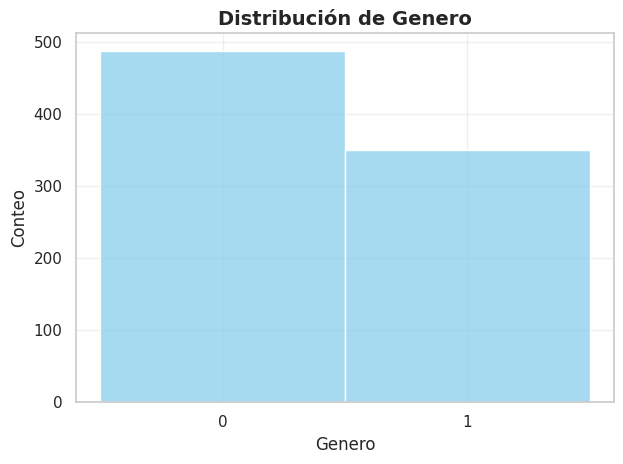

Valores en la columna 'Genero':
Gender
0    488
1    351
Name: count, dtype: int64




In [141]:
# Genero
ax = sns.histplot(data=df, x='Gender', discrete=True, stat='count', color="skyblue")

plt.title("Distribución de Genero", fontsize=14, weight='bold')
plt.xlabel("Genero", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.grid(alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print("Valores en la columna 'Genero':")
print(df['Gender'].value_counts())
print("\n")

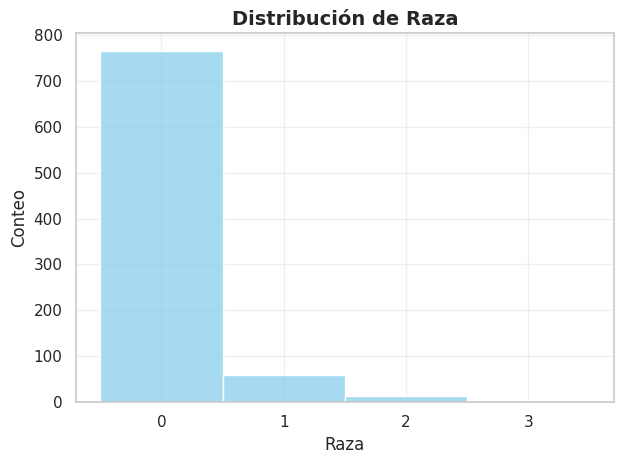

Valores en la columna 'Race':
Race
0    765
1     59
2     14
3      1
Name: count, dtype: int64




In [142]:
# Raza
ax = sns.histplot(data=df, x='Race',discrete=True, stat='count', color="skyblue")

plt.title("Distribución de Raza", fontsize=14, weight='bold')
plt.xlabel("Raza", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.grid(alpha=0.3)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
print("Valores en la columna 'Race':")
print(df['Race'].value_counts())
print("\n")

Text(0, 0.5, 'Edad de Diagnóstico')

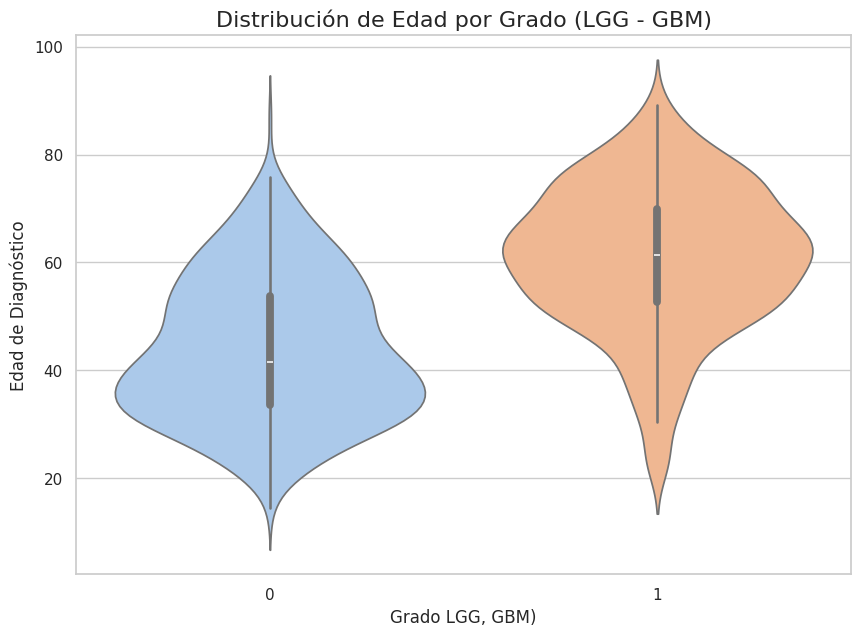

In [143]:
plt.figure(figsize=(10, 7))

# Grafico de violin.
sns.violinplot(x='Grade', y='Age_at_diagnosis', data=df, hue='Grade', legend=False, palette='pastel')

# Añadir títulos y etiquetas
plt.title('Distribución de Edad por Grado (LGG - GBM)', fontsize=16)
plt.xlabel('Grado LGG, GBM)', fontsize=12)
plt.ylabel('Edad de Diagnóstico', fontsize=12)




Text(0, 0.5, 'Edad de Diagnóstico')

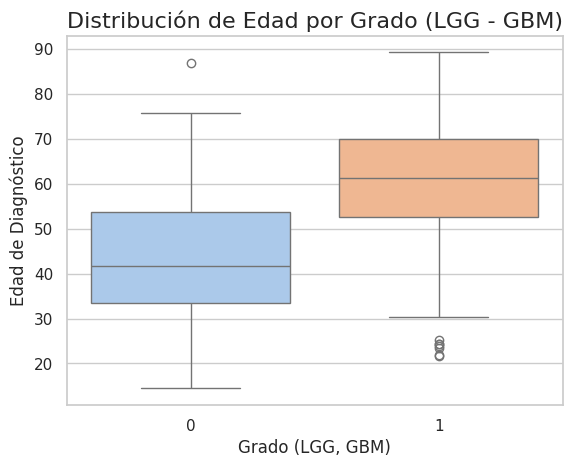

In [144]:
# Grafico de Caja
sns.boxplot(x='Grade', y='Age_at_diagnosis', data=df,hue='Grade', legend=False, palette='pastel')

# 2. Añadir títulos y etiquetas
plt.title('Distribución de Edad por Grado (LGG - GBM)', fontsize=16)
plt.xlabel('Grado (LGG, GBM)', fontsize=12)
plt.ylabel('Edad de Diagnóstico', fontsize=12)

Matriz de correlación:
                     Grade    Gender  Age_at_diagnosis      IDH1      TP53  \
Grade             1.000000 -0.060033          0.529203 -0.708141 -0.161786   
Gender           -0.060033  1.000000         -0.016337  0.048282  0.002022   
Age_at_diagnosis  0.529203 -0.016337          1.000000 -0.568892 -0.315863   
IDH1             -0.708141  0.048282         -0.568892  1.000000  0.340995   
TP53             -0.161786  0.002022         -0.315863  0.340995  1.000000   
ATRX             -0.314625  0.056376         -0.418411  0.454920  0.546903   
PTEN              0.367174 -0.032233          0.259421 -0.394862 -0.067829   
EGFR              0.241527 -0.034497          0.227660 -0.357217 -0.173952   
CIC              -0.303459  0.061063         -0.122851  0.320696 -0.278753   
MUC16             0.119447  0.015054          0.089834 -0.097956  0.017712   
PIK3CA            0.028905 -0.004629          0.050064 -0.052062 -0.071061   
NF1               0.088123 -0.009179     

<Figure size 2000x1700 with 0 Axes>

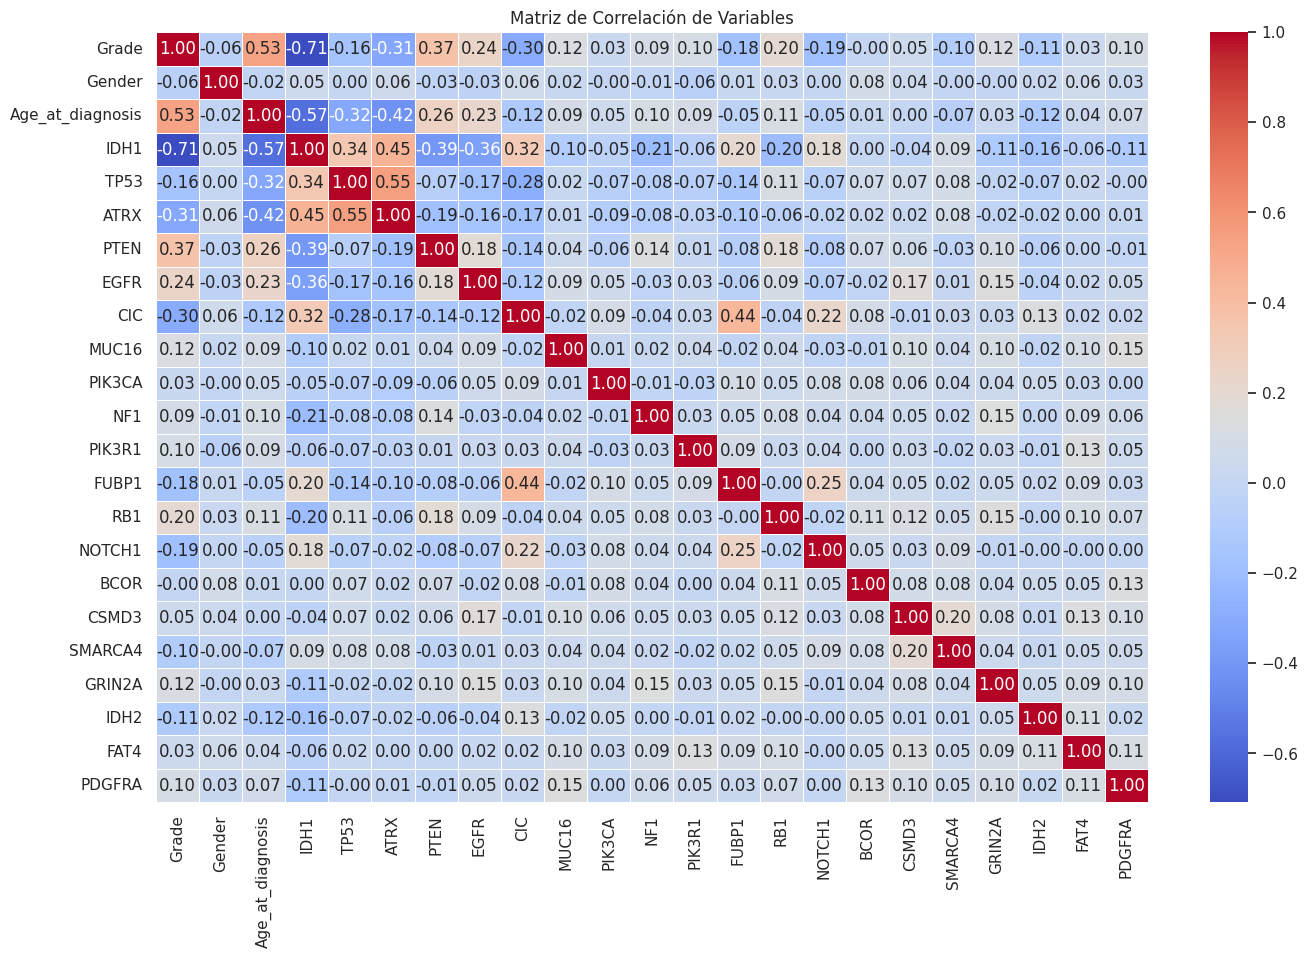

In [145]:
# Excluiremos 'Race' del mapa de calor, ya que es una variable muy desbalanceada
df_corr = df.drop(columns=['Race'])

# Calcular la matriz de correlación
corr_matrix = df_corr.corr()
plt.figure(figsize=(20, 17))


# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(corr_matrix)

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

🧠 Reflexiona:

¿Existen clases desbalanceadas?

Sí, por ejemplo "Race" esta muy desbalanceada, por lo cual fue eliminada en la matriz de correlación.

¿Qué atributos parecen más informativos?

Las columnas que muestran correlación con Grade son: 'Age_at_diagnosis', 'IDH1', 'ATRX', 'PTEN' y 'EGFR'



# 3. Gráfica de Errores en Entrenamiento y Prueba

* En este ejercicio vas a entrenar un árbol de decisión con diferentes profundidas. Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10
* Los valores de las profundides a evaluar son 2, 5, 10, 15, 20, 25, 30 y None
* Deberás usar StratifiedKFold con 10 particiones, y un valor aleaotorio de 3
* Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades
* Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring ="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7
* Muestra una gráfica para los distintos resultados  cuando se usa F1 Macro


RESULTADOS (Promedio de 10 Folds)
Profundidad          2: Train F1 Macro = 0.8691, Test F1 Macro = 0.8678
Profundidad          5: Train F1 Macro = 0.8844, Test F1 Macro = 0.8565
Profundidad         10: Train F1 Macro = 0.9241, Test F1 Macro = 0.8107
Profundidad         15: Train F1 Macro = 0.9726, Test F1 Macro = 0.7951
Profundidad         20: Train F1 Macro = 0.9957, Test F1 Macro = 0.7858
Profundidad         25: Train F1 Macro = 0.9992, Test F1 Macro = 0.7881
Profundidad         30: Train F1 Macro = 1.0000, Test F1 Macro = 0.7853
Profundidad None (Max): Train F1 Macro = 1.0000, Test F1 Macro = 0.7853


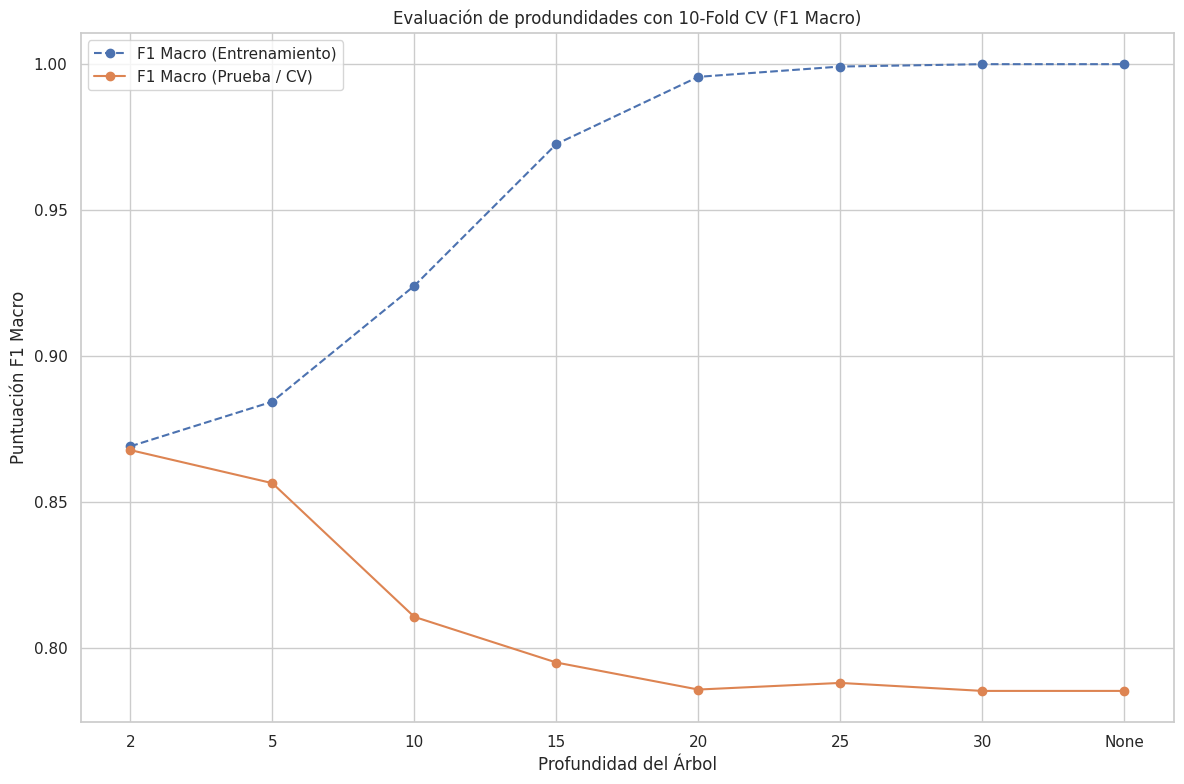

In [146]:
# Definir X (features) y y (target)
y = df['Grade']
# 'X' son todas las columnas excepto 'Grade' y 'Race'
X = df.drop(columns=['Grade', 'Race'])

# Parámetros a evaluar
profundidades = [2, 5, 10, 15, 20, 25, 30, None]

# Crear el objeto de Validación Cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

# Almacenar resultados
resultados_train_mean = []
resultados_test_mean = []

# Entrenamiento y evaluación
for prof in profundidades:
    clf = DecisionTreeClassifier(max_depth=prof, random_state=42)

    scores = cross_validate(
        clf,
        X, y,
        cv=cv,
        scoring='f1_macro',
        return_train_score=True
    )

    # Almacenar los scores de las 10 particiones
    resultados_train_mean.append(np.mean(scores['train_score']))
    resultados_test_mean.append(np.mean(scores['test_score']))

print("\nRESULTADOS (Promedio de 10 Folds)")

# Imprimir resultados
profundidades_str_print = [str(p) if p is not None else "None (Max)" for p in profundidades]

for i, depth in enumerate(profundidades_str_print):
    print(f"Profundidad {depth:>10}: Train F1 Macro = {resultados_train_mean[i]:.4f}, Test F1 Macro = {resultados_test_mean[i]:.4f}")

# Graficar los resultados
profundidades_str_plot = [str(p) for p in profundidades]

plt.figure(figsize=(12, 8))
plt.plot(profundidades_str_plot, resultados_train_mean, label='F1 Macro (Entrenamiento)', marker='o', linestyle='--')
plt.plot(profundidades_str_plot, resultados_test_mean, label='F1 Macro (Prueba / CV)', marker='o', linestyle='-')
plt.xlabel('Profundidad del Árbol')
plt.ylabel('Puntuación F1 Macro')
plt.title('Evaluación de produndidades con 10-Fold CV (F1 Macro)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 4. Optimización de hiperparámetros con RandomizedSearchCV

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: f1 Macro
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [147]:
#Árbol de Decisión con RandomizedSearchCV y StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from scipy.stats import randint

In [148]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/TCGA_InfoWithGrade.csv')

In [149]:
# Definir X (features) y y (target)
y = df['Grade']
# 'X' son todas las columnas excepto 'Grade' y 'Race'
X = df.drop(columns=['Grade', 'Race'])


In [150]:
%%time
# Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# Definir espacio de búsqueda
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 51),
    'min_samples_split': randint(2, 21)
}

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=5,              # Número de combinaciones aleatorias a probar
    cv=cv,
    scoring='f1_macro', # Metrica F1 Macro
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo
random_search.fit(X, y)

# Resultados
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print(f"Best score:{random_search.best_score_:.4f}")


Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 23, 'min_samples_split': 12}
Best score:0.8317
CPU times: user 68.1 ms, sys: 3.59 ms, total: 71.7 ms
Wall time: 683 ms


# 5. Optimización de hiperparámetros con GridSearchCV

* Define el espacio de búsqueda  para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [151]:
#Árbol de Decisión con GridSearchCV y StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from scipy.stats import randint

In [152]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/TCGA_InfoWithGrade.csv')

In [153]:
# Definir X (features) y y (target)
y = df['Grade']
# 'X' son todas las columnas excepto 'Grade' y 'Race'
X = df.drop(columns=['Grade', 'Race'])


In [154]:
%%time
# Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# Definir espacio de búsqueda
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(5, 51)),
    'min_samples_split': list(range(2, 21))
}

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro', # Metrica F1 Macro
    n_jobs=-1
    )


# Ajustar el modelo
grid_search.fit(X, y)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Best score:{grid_search.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 12}
Best score:0.8640
CPU times: user 9.73 s, sys: 514 ms, total: 10.2 s
Wall time: 2min 32s


# 6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy

* Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* n_iter = 5 (combinaciones aleatorias a buscar)
* n_jobs = -1 para acelerar cómputo
* Métrica de evaluación: accuracy
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score


In [155]:
#Árbol de Decisión con RandomizedSearchCV y StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import randint

In [156]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/TCGA_InfoWithGrade.csv')

In [157]:
# Definir X (features) y y (target)
y = df['Grade']
# 'X' son todas las columnas excepto 'Grade' y 'Race'
X = df.drop(columns=['Grade', 'Race'])


In [158]:
%%time
# Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# Definir espacio de búsqueda
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 51),
    'min_samples_split': randint(2, 21)
}

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=5,              # Número de combinaciones aleatorias a probar
    cv=cv,
    scoring='accuracy', # Metrica accuracy
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo
random_search.fit(X, y)

# Resultados
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print(f"Best score:{random_search.best_score_:.4f}")


Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 23, 'min_samples_split': 12}
Best score:0.8367
CPU times: user 65.2 ms, sys: 2.08 ms, total: 67.2 ms
Wall time: 385 ms


# 7. Optimización de hiperparámetros con GridSearchCV: accuracy

* Define el espacio de búsqueda  para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
* Usa el árbol de decisión
* StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
* Métrica de evaluación: f1 Macro
* n_jobs = -1 para acelerar cómputo
* Imprime los mejores hiperparámetros encontrados
* Imprime el best_score

In [159]:
#Árbol de Decisión con GridSearchCV y StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import randint

In [160]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/TCGA_InfoWithGrade.csv')

In [161]:
# Definir X (features) y y (target)
y = df['Grade']
# 'X' son todas las columnas excepto 'Grade' y 'Race'
X = df.drop(columns=['Grade', 'Race'])


In [162]:
%%time
# Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# Definir espacio de búsqueda
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 51),
    'min_samples_split': range(2, 21)
}

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy', # Metrica accuracy
    n_jobs=-1
    )


# Ajustar el modelo
grid_search.fit(X, y)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Best score:{grid_search.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best score:0.8653
CPU times: user 7.35 s, sys: 277 ms, total: 7.62 s
Wall time: 2min 2s


# 8. Actividad de reflexión y análisis

* ¿Cuál método encontró mejores hiperparámetros?

El GridSearchCV con la métrica accuracy logró encontrar los mejores hiperparámetros, además de un score de 0.8653

* ¿Cuál fue más costoso computacionalmente?

El GridSearchCV con la métrica F1 Score tuvo el mayor costo computacional, CPU times: user 9.73 s, sys: 514 ms, total: 10.2 s Wall time: 2min 32s


* ¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? Sí

¿Por qué? GridSearchCV utiliza un método de "fuerza bruta", probando las múltiples combinaciones, mientras que el RandomizedSearchCV solo prueba con 5 combinaciones al aleatorias.

* ¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? Sí

¿Por qué? GridSearchCV utiliza un método de "fuerza bruta", probando las múltiples combinaciones, mientras que el RandomizedSearchCV solo prueba con 5 combinaciones al aleatorias.

* ¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?

En el caso de RandomizedSearchCV sí, para el GridSearchCV solo el min_samples_split fue diferente con f1 macro= 12 y con accuracy = 2